# MERIT · ICLR 2027 — reproduction notebook

This notebook rebuilds **every figure, table and number** in
*MERIT: Making Every Modality Earn Its Contribution in Multimodal Attention
Decoding* (`docs/iclr2027/`), and re-scores the **released checkpoints**
(`weights/merit/`, 26 files) on their exact test folds.

Nothing in the paper is typed by hand: every result cell is `\R{key}`, resolved
from `results_macros.tex`, which this notebook regenerates from the measured run
outputs. The run outputs live on scratch (purged by OSC) **and** in the tracked
snapshot `docs/iclr2027/results/`, so everything here works from the repository
alone.

| section | what it does |
|---|---|
| 1 | how every number was produced (the training jobs; optionally submit them) |
| 2 | refresh the tracked results snapshot from scratch |
| 3 | regenerate `results_macros.tex` and render the paper's tables |
| 4 | regenerate the paper's figures |
| 5 | load all 26 released checkpoints (`strict=True`) and compare to the paper |
| 6 | re-score checkpoints on their exact test folds (deterministic) |
| 7 | build the PDF |

Run on an OSC login/compute node with the `nips` conda env. Sections 3–5 need
only the repo; section 6 additionally needs the windowed data cache (or the
`maestro-eeg-dataset` tree on scratch to rebuild it); sections 1–2 need scratch.

In [1]:
import glob, io, json, os, re, subprocess, sys, time
from pathlib import Path

import numpy as np
import pandas as pd

# resolve the repository root (the notebook lives in notebooks/)
REPO = Path.cwd()
while not (REPO / "src" / "tools" / "make_macros.py").exists():
    assert REPO != REPO.parent, "run from inside the repository"
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))

PAPER = REPO / "docs" / "iclr2027"
SNAP = PAPER / "results"                       # tracked snapshot of run outputs
WEIGHTS = REPO / "weights" / "merit"
SCRATCH = Path("/fs/scratch/PAS2301/alialavi/projects")

# ---- switches ---------------------------------------------------------------
SUBMIT_TRAINING = False   # section 1: sbatch the full experiment grid
RUN_SELFTEST    = False   # section 1: CPU smoke of the whole stack (synthetic data)
RESCORE         = "one"   # section 6: "none" | "one" (one fold per family) | "all"
BUILD_PDF       = False   # section 7: latexmk

pd.set_option("display.width", 200)
print(f"repo    : {REPO}")
print(f"python  : {sys.version.split()[0]}  ({sys.executable})")
print(f"scratch : {'present' if SCRATCH.is_dir() else 'ABSENT (snapshot only)'}")
print(f"snapshot: {len(list((SNAP / 'runs').glob('*/results.parquet')))} run results tracked")

repo    : /users/PAS2301/alialavi/projects/multimodal_aad_dataset_osu
python  : 3.11.14  (/users/PAS2301/alialavi/miniconda3/envs/nips/bin/python3.11)
scratch : present
snapshot: 69 run results tracked


## 1 · How every number was produced

Each experiment is one SLURM job over the shared data/model/runner stack
(`python -m src.main`, hydra config `configs/`). The tag recovered from the run
directory routes each result to its macro keys, so tables never mix experiments.

| sbatch (`analysis/slurm_scripts/`) | tag(s) | feeds |
|---|---|---|
| `merit_certify.sbatch` | — | audio-only probe & role-separation tables |
| `merit_within.sbatch EXP=ladder_raw` / `EXP=ladder_qm` | `ladder_raw`, `ladder_qm` | ablation ladder |
| `merit_within.sbatch EXP=streams` | `streams` | per-stream credit |
| `merit_within.sbatch EXP=hinge` | `hinge` | the freeloading experiment |
| `merit_within.sbatch EXP=lag` | `lag_qm`, `lag_mm` | neural directionality |
| `merit_within.sbatch EXP=orientfree` | `mm3`, `mm2` | same-talker negatives |
| `merit_hinge2loso.sbatch` + `merit_v2.sbatch` | `v2hinge2`, `v2hinge2loso`, `v2onset`, … | **headline 2×2, LOSO, EEG-only** |
| `merit_loso.sbatch` (array 0–15) | `loso` | leave-one-listener-out |
| `merit_windows.sbatch` (array 0–4) | `w5`…`w30` | decision-window sweep |
| `merit_external*.sbatch` | `extkul*`, `extdtu*`, `extnju*` | public-corpus transfer |
| `merit_release.sbatch` (array 0–2) | `release`, `releaseloso`, `releaseeeg` | **the released checkpoints** |

The next cell prints the submission commands; flip `SUBMIT_TRAINING = True` to
actually queue them (GPU, account `PAS2966`). The released weights in
`weights/merit/` come from `merit_release.sbatch`, which retrains the three
headline models with `runner.save_models=true`.

In [2]:
JOBS = ["sbatch analysis/slurm_scripts/merit_certify.sbatch",
        "EXP=ladder_raw sbatch analysis/slurm_scripts/merit_within.sbatch",
        "EXP=ladder_qm  sbatch analysis/slurm_scripts/merit_within.sbatch",
        "EXP=streams    sbatch analysis/slurm_scripts/merit_within.sbatch",
        "EXP=hinge      sbatch analysis/slurm_scripts/merit_within.sbatch",
        "EXP=lag        sbatch analysis/slurm_scripts/merit_within.sbatch",
        "EXP=orientfree sbatch analysis/slurm_scripts/merit_within.sbatch",
        "sbatch analysis/slurm_scripts/merit_hinge2loso.sbatch",
        "sbatch analysis/slurm_scripts/merit_v2.sbatch",
        "sbatch analysis/slurm_scripts/merit_loso.sbatch",
        "sbatch analysis/slurm_scripts/merit_windows.sbatch",
        "sbatch analysis/slurm_scripts/merit_release.sbatch"]
for j in JOBS:
    print(("submitting: " if SUBMIT_TRAINING else "") + j)
    if SUBMIT_TRAINING:
        subprocess.run(j, shell=True, check=True)

sbatch analysis/slurm_scripts/merit_certify.sbatch
EXP=ladder_raw sbatch analysis/slurm_scripts/merit_within.sbatch
EXP=ladder_qm  sbatch analysis/slurm_scripts/merit_within.sbatch
EXP=streams    sbatch analysis/slurm_scripts/merit_within.sbatch
EXP=hinge      sbatch analysis/slurm_scripts/merit_within.sbatch
EXP=lag        sbatch analysis/slurm_scripts/merit_within.sbatch
EXP=orientfree sbatch analysis/slurm_scripts/merit_within.sbatch
sbatch analysis/slurm_scripts/merit_hinge2loso.sbatch
sbatch analysis/slurm_scripts/merit_v2.sbatch
sbatch analysis/slurm_scripts/merit_loso.sbatch
sbatch analysis/slurm_scripts/merit_windows.sbatch
sbatch analysis/slurm_scripts/merit_release.sbatch


In [3]:
# CPU smoke test of the full stack (synthetic data, wandb disabled, ~minutes)
if RUN_SELFTEST:
    subprocess.run([sys.executable, "-m", "src.main", "mode=selftest"], check=True)
else:
    print("skipped (set RUN_SELFTEST = True)")

skipped (set RUN_SELFTEST = True)


## 2 · Refresh the tracked results snapshot

`src.tools.snapshot_results` copies every non-smoke `results.parquet` (plus the
candidate-probe / role-separation / external-corpus CSVs) from scratch into
`docs/iclr2027/results/`. `make_macros` and `make_figures` read scratch when it
exists and the snapshot otherwise, and duplicated rows collapse by run name —
so this cell is a no-op when scratch is gone, and the paper still builds.

In [4]:
if SCRATCH.is_dir():
    from src.tools.snapshot_results import snapshot
    snapshot()
else:
    print("scratch absent -- keeping the tracked snapshot as-is")

from src.tools.make_macros import load
DF = load()
inv = (DF.groupby(["tag", "protocol"])
         .agg(variants=("variant", "nunique"), folds=("split", "nunique"),
              window=("window_sec", "first"), cand=("cand_mode", "first"),
              K=("K", "first")))
print(f"{len(DF)} result rows across {DF['tag'].nunique()} experiment tags")
inv

69 run results + 8 csv files -> /users/PAS2301/alialavi/projects/multimodal_aad_dataset_osu/docs/iclr2027/results


1272 result rows across 40 experiment tags


,,variants,folds,window,cand,K
tag,protocol,,,,,
extdtuloso,loso,3,18,10.0,qmatch,2
extdtuloso5,loso,3,18,5.0,qmatch,2
extdtuwithin,within,3,5,10.0,qmatch,2
extdtuwithin5,within,3,5,5.0,qmatch,2
extdtuwithinst,within,3,5,10.0,shifted_qm,2
extkulloso,loso,3,16,10.0,qmatch,2
extkulloso5,loso,3,16,5.0,qmatch,2
extkulwithin,within,3,5,10.0,qmatch,2
extkulwithin5,within,3,5,5.0,qmatch,2


## 3 · Tables — regenerate `results_macros.tex`

Every number in the manuscript resolves from this file; a key with no
measurement renders as a red `??` in the PDF. After regenerating, the paper's
main tables are rendered below as dataframes (mean over folds, as the macros
aggregate them).

In [5]:
r = subprocess.run([sys.executable, "-m", "src.tools.make_macros",
                    "--out", str(PAPER / "results_macros.tex")],
                   capture_output=True, text=True, check=True)
print(r.stdout[-600:])

# parse the macros back so numbers can be checked programmatically
R = dict(re.findall(r"\\defres\{(.+?)\}\{(.+?)\}",
                    (PAPER / "results_macros.tex").read_text()))
print(f"{len(R)} macros defined")
HEADLINE = {
    "fused MERIT, within listeners (Table 1)": "v2hinge2/H4_nohinge_nodrop/within/acc",
    "fused MERIT, unseen listeners (App. J)":  "v2hinge2loso/H4_nohinge_nodrop/loso/acc",
    "EEG-only MERIT, within listeners (Table 2)": "v2onset/V4_subjadapt/within/acc",
}
for name, key in HEADLINE.items():
    assert key in R, f"missing macro: {key}"
    print(f"  {name:46s} \\R{{{key}}} = {R[key]}")

  within       5
w5               all                  within       5
                 behaviour            within       5
                 eeg                  within       5
                 eeg_flow             within       5
                 eeg_fovea            within       5
                 eeg_gaze             within       5
                 eeg_imu              within       5
                 flow                 within       5
                 fovea                within       5
                 gaze                 within       5
                 imu                  within       5

8217 macros defined
  fused MERIT, within listeners (Table 1)        \R{v2hinge2/H4_nohinge_nodrop/within/acc} = 0.8173
  fused MERIT, unseen listeners (App. J)         \R{v2hinge2loso/H4_nohinge_nodrop/loso/acc} = 0.7438
  EEG-only MERIT, within listeners (Table 2)     \R{v2onset/V4_subjadapt/within/acc} = 0.6915


In [6]:
from src.tools.make_macros import PREF, STREAMS

def battery_table(tag, protocol=None):
    "Core battery per variant for one experiment tag (mean/sd over folds)."
    g = DF[DF["tag"] == tag]
    if protocol:
        g = g[g["protocol"] == protocol]
    cols = {"acc": "acc", "null_mean": "null", "contribution": "contrib",
            "p_perm": "p", "flip_rate": "flip"}
    have = {PREF + c: n for c, n in cols.items() if PREF + c in g}
    t = g.groupby(["protocol", "variant"])[list(have)].agg(["mean", "std"])
    t.columns = [f"{have[c]}.{s}" for c, s in t.columns]
    n = g.groupby(["protocol", "variant"]).size().rename("folds")
    return t.join(n).round(4)

def credit_table(tag):
    "Per-stream Shapley credit for one experiment tag."
    g = DF[DF["tag"] == tag]
    cols = {PREF + f"shapley_{m}": f"phi/{m}" for m in STREAMS
            if PREF + f"shapley_{m}" in g and g[PREF + f"shapley_{m}"].notna().any()}
    cols[PREF + "contribution"] = "total"
    t = g.groupby(["protocol", "variant"])[list(cols)].mean()
    t.columns = [cols[c] for c in t.columns]
    return t.round(4)

In [7]:
# Table 1 & Fig. 2 source -- the clean 2x2 (hinge x modality dropout), fused streams.
# MERIT is H4: no hinge, no dropout.
battery_table("v2hinge2")

acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean  p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                        
within   H1_hinge_drop        0.7884   0.0329     0.2774    0.0165        0.5111       0.0336   0.005    0.0     0.7361    0.0100      5
         H2_nohinge_drop      0.8091   0.0153     0.2793    0.0247        0.5298       0.0276   0.005    0.0     0.7389    0.0059      5
         H3_hinge_nodrop      0.8242   0.0382     0.2685    0.0160        0.5557       0.0226   0.005    0.0     0.7402    0.0038      5
         H4_nohinge_nodrop    0.8173   0.0259     0.2733    0.0189        0.5439       0.0321   0.005    0.0     0.7389    0.0056      5

In [8]:
# Appendix J / abstract -- the same 2x2 on unseen listeners (16-fold LOSO)
battery_table("v2hinge2loso")

acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                         
loso     H1_hinge_drop        0.7469   0.2020     0.2785    0.0413        0.4684       0.1825  0.0062  0.0050     0.6790    0.0627     16
         H2_nohinge_drop      0.7625   0.1698     0.2827    0.0193        0.4798       0.1606  0.0183  0.0535     0.7050    0.0359     16
         H3_hinge_nodrop      0.7219   0.2137     0.2708    0.0430        0.4511       0.1816  0.0081  0.0072     0.6845    0.0713     16
         H4_nohinge_nodrop    0.7438   0.1931     0.2701    0.0260        0.4737       0.1851  0.0227  0.0576     0.7115    0.0453     16

In [9]:
# Table 2 source -- EEG-only ladder (V4_subjadapt is EEG-only MERIT)
battery_table("v2onset")

acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean  p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                   
within   V1_crops        0.4956   0.0600     0.2982    0.0420        0.1974       0.0295   0.005    0.0     0.6738    0.0472      5
         V2_trial        0.6676   0.0612     0.3810    0.0468        0.2866       0.0537   0.005    0.0     0.6501    0.0884      5
         V3_causal       0.6502   0.0354     0.3231    0.0647        0.3271       0.0340   0.005    0.0     0.7001    0.0266      5
         V3b_acausal     0.6145   0.0890     0.4017    0.1078        0.2127       0.0378   0.005    0.0     0.5937    0.0548      5
         V4_subjadapt    0.6915   0.0552     0.2944    0.0339        0.3971       0.0398   0.005    0.0     0.7286    0.0099      5

In [10]:
# per-stream Shapley credit behind the credit figure, within and unseen listeners
from IPython.display import display
display(credit_table("v2hinge2"))
display(credit_table("v2hinge2loso"))

phi/eeg  phi/gaze  phi/imu  phi/video  phi/fovea   total
protocol variant                                                                    
within   H1_hinge_drop       0.1600    0.0362   0.0144     0.0247     0.2758  0.5111
         H2_nohinge_drop     0.2229    0.0206   0.0079     0.0128     0.2656  0.5298
         H3_hinge_nodrop     0.2169    0.0340   0.0074     0.0295     0.2679  0.5557
         H4_nohinge_nodrop   0.2217    0.0194   0.0039     0.0123     0.2866  0.5439

phi/eeg  phi/gaze  phi/imu  phi/video  phi/fovea   total
protocol variant                                                                    
loso     H1_hinge_drop       0.1149    0.0331   0.0145     0.0326     0.2733  0.4684
         H2_nohinge_drop     0.1560    0.0385   0.0106     0.0245     0.2502  0.4798
         H3_hinge_nodrop     0.1479    0.0259   0.0131     0.0352     0.2289  0.4511
         H4_nohinge_nodrop   0.1762    0.0250   0.0127     0.0182     0.2416  0.4737

In [11]:
# the freeloading experiment (hinge), ablation ladders, same-talker negatives,
# lag control, and the decision-window sweep -- every remaining MAESTRO tag
for tag in ["hinge", "ladder_raw", "ladder_qm", "streams", "mm3", "mm2",
            "lag_qm", "lag_mm", "loso"] + sorted(
                t for t in DF["tag"].unique() if re.fullmatch(r"w\d+", t)):
    if (DF["tag"] == tag).any():
        print(f"### {tag}")
        display(battery_table(tag))

### hinge


acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean  p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                          
within   all_hinge_accsel       0.7087   0.0131     0.2602    0.0086        0.4486       0.0206  0.0476    0.0     0.7381    0.0075      5
         all_hinge_credsel      0.7088   0.0230     0.2614    0.0049        0.4473       0.0266  0.0476    0.0     0.7346    0.0068      5
         all_hinge_nodrop       0.7007   0.0105     0.2549    0.0052        0.4458       0.0140  0.0476    0.0     0.7404    0.0041      5
         all_hinge_uniform      0.7283   0.0275     0.2594    0.0036        0.4688       0.0294  0.0476    0.0     0.7392    0.0029      5
         all_nohinge_accsel     0.7154   0.0278     0.2600    0.0091        0.4554       0.0308  0.0476    0.0     0.7388    0.0065      5
         all_nohinge_credsel    0.7250   0.0259     0.2639    0.0079        0.4611       0.0194  0.0476    0.0     0.7328    0.0133      5
         all_nohinge_nodrop     0.7226   0.0167     0.2542    0.0047        0.4684       0.0180  0.0476    0.0     0.7444    0.0039      5

### ladder_raw


acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                           
within   L0_published           0.4991   0.1061     0.4991    0.1061        0.0000       0.0000  1.0000  0.0000     0.0000    0.0000      5
         L1_encoder             0.5800   0.0849     0.5800    0.0849        0.0000       0.0000  1.0000  0.0000     0.0000    0.0000      5
         L2_corr_head           0.5732   0.0996     0.5718    0.1000        0.0014       0.0022  0.4286  0.2308     0.0414    0.0203      5
         L3_anti_shortcut       0.5958   0.0801     0.5878    0.0832        0.0080       0.0101  0.2000  0.1321     0.1071    0.1086      5
         L4_contribution_sel    0.5502   0.0235     0.4210    0.0787        0.1293       0.0792  0.2286  0.4046     0.4704    0.1438      5
         L5_credit              0.5631   0.0337     0.4094    0.0284        0.1536       0.0163  0.0476  0.0000     0.4968    0.0225      5

### ladder_qm


...

acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                 
within   all          0.7297   0.0070     0.2578    0.0069        0.4719       0.0078  0.0476  0.0000     0.7423    0.0029      5
         eeg          0.4137   0.1160     0.2446    0.0148        0.1691       0.1038  0.1619  0.2556     0.7191    0.0179      5
         eeg_fovea    0.6990   0.0509     0.2502    0.0105        0.4488       0.0471  0.0476  0.0000     0.7451    0.0051      5
         eeg_gaze     0.5062   0.0829     0.2505    0.0145        0.2557       0.0694  0.0476  0.0000     0.7216    0.0147      5

### w30


acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean  p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                
within   all          0.7628   0.0233     0.2601    0.0077        0.5027       0.0261  0.0476    0.0     0.7395    0.0063      5
         eeg          0.6226   0.0424     0.2706    0.0233        0.3520       0.0268  0.0476    0.0     0.7316    0.0177      5
         eeg_fovea    0.7353   0.0342     0.2635    0.0107        0.4717       0.0339  0.0476    0.0     0.7357    0.0080      5
         eeg_gaze     0.6375   0.0664     0.2698    0.0166        0.3678       0.0664  0.0476    0.0     0.7274    0.0095      5

### w5


acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                 
within   all          0.7189   0.0193     0.2642    0.0057        0.4547       0.0178  0.0050  0.0000     0.7355    0.0028      5
         behaviour    0.6857   0.0459     0.2575    0.0041        0.4282       0.0470  0.0050  0.0000     0.7414    0.0044      5
         eeg          0.3954   0.0678     0.3101    0.0258        0.0853       0.0492  0.0418  0.0823     0.5086    0.1500      5
         eeg_flow     0.4994   0.0233     0.3003    0.0147        0.1992       0.0135  0.0050  0.0000     0.6247    0.0370      5
         eeg_fovea    0.7198   0.0145     0.2748    0.0045        0.4450       0.0171  0.0050  0.0000     0.7235    0.0073      5
         eeg_gaze     0.4845   0.0441     0.2927    0.0297        0.1918       0.0199  0.0050  0.0000     0.6478    0.0332      5
         eeg_imu      0.4914   0.0198     0.3198    0.0141        0.1716       0.0100  0.0050  0.0000     0.6125    0.0265      5
         flow         0.4126   0.0286     0.2458    0.0173        0.1668       0.0206  0.0050  0.0000     0.7185    0.0145      5
         fovea        0.7096   0.0126     0.2566    0.0033        0.4530       0.0154  0.0050  0.0000     0.7441    0.0044      5
         gaze         0.3349   0.0571     0.2236    0.0306        0.1113       0.0299  0.0050  0.0000     0.6687    0.0696      5
         imu          0.3800   0.0224     0.2456    0.0176        0.1345       0.0156  0.0050  0.0000     0.7286    0.0136      5

In [12]:
# public-corpus transfer (KU Leuven, DTU, NJU) + the audio-only probe / role
# separation acceptance tables
for tag in sorted(t for t in DF["tag"].unique() if t.startswith("ext")):
    print(f"### {tag}")
    display(battery_table(tag))

from src.tools.make_macros import find_aux
for name in ("credit_candidate_probes.csv", "credit_role_separation.csv"):
    f = find_aux(name)
    if f:
        print(f"### {name}")
        display(pd.read_csv(f).round(4))

### extdtuloso


acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                   
loso     eeg_acausal    0.7052   0.0878     0.4992    0.0243        0.2060       0.0928  0.0395  0.0555     0.4915    0.0192     18
         eeg_causal     0.6991   0.0801     0.4985    0.0216        0.2006       0.0914  0.0564  0.1190     0.4951    0.0142     18
         eeg_centred    0.7269   0.0869     0.5005    0.0254        0.2264       0.0952  0.0238  0.0359     0.4954    0.0207     18

### extdtuloso5


acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                   
loso     eeg_acausal    0.6684   0.0811     0.4976    0.0152        0.1708       0.0778  0.0279  0.0442     0.4937    0.0091     18
         eeg_causal     0.6676   0.0754     0.4987    0.0113        0.1689       0.0741  0.0210  0.0253     0.4964    0.0108     18
         eeg_centred    0.6635   0.0728     0.4986    0.0164        0.1649       0.0715  0.0238  0.0357     0.4940    0.0098     18

### extdtuwithin


...

acc.mean  acc.std  null.mean  null.std  contrib.mean  contrib.std  p.mean   p.std  flip.mean  flip.std  folds
protocol variant                                                                                                                   
within   eeg_acausal    0.5039   0.0201     0.5013    0.0013        0.0026       0.0203  0.4179  0.4646     0.4720    0.0406      5
         eeg_causal     0.5103   0.0105     0.4998    0.0016        0.0105       0.0117  0.2687  0.2842     0.4639    0.0201      5
         eeg_centred    0.4994   0.0110     0.4977    0.0037        0.0017       0.0112  0.4488  0.3242     0.3968    0.0867      5

### credit_candidate_probes.csv


,construction,K,audio_only_probe,chance,excess,window_sec,n_windows
0,raw,4,0.5581,0.2500,0.3081,10.0,7990
1,qmatch,4,0.2603,0.2500,0.0103,10.0,7990
2,shifted,3,0.3758,0.3333,0.0425,10.0,7990
3,shifted_qm,3,0.3564,0.3333,0.0231,10.0,7990
4,shifted,2,0.5131,0.5000,0.0131,10.0,7990
5,shifted_qm,2,0.5134,0.5000,0.0134,10.0,7990


### credit_role_separation.csv


,statistic,auc,cohen_d,target_mean,masker_mean
0,kurtosis,0.2238,-0.5760,0.0701,2.5213
1,skew,0.2493,-0.8516,0.8230,1.3446
2,p95-p5,0.5643,0.2441,2.9006,2.8339
3,silence frac,0.4792,-0.0280,0.4220,0.4237
4,rel. power 0.5-4 Hz,0.5113,0.0446,0.5942,0.5906
5,rel. power 4-8 Hz,0.4451,-0.2102,0.1958,0.2083
6,rel. power 8-20 Hz,0.4225,-0.3080,0.0790,0.0890
7,Gini sparsity,0.3399,-0.5751,0.3362,0.3621
8,envelope crest (dB),NaN,-1.2152,9.7541,12.4139


## 4 · Figures

`src.tools.make_figures` draws both manuscript figures from the same loaded
results (PDF into the paper, PNG twin for this notebook).

In [13]:
from src.tools import make_figures as MF
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9, "axes.labelsize": 9,
                     "savefig.dpi": 200, "pdf.fonttype": 42})
probes_f = find_aux("credit_candidate_probes.csv")
probes = pd.read_csv(probes_f) if probes_f else None
out = str(PAPER / "figs")
MF.window_sweep(DF, probes, out)
MF.credit_bars(DF, out)

wrote window_sweep.pdf/.png


wrote credit_bars.pdf/.png


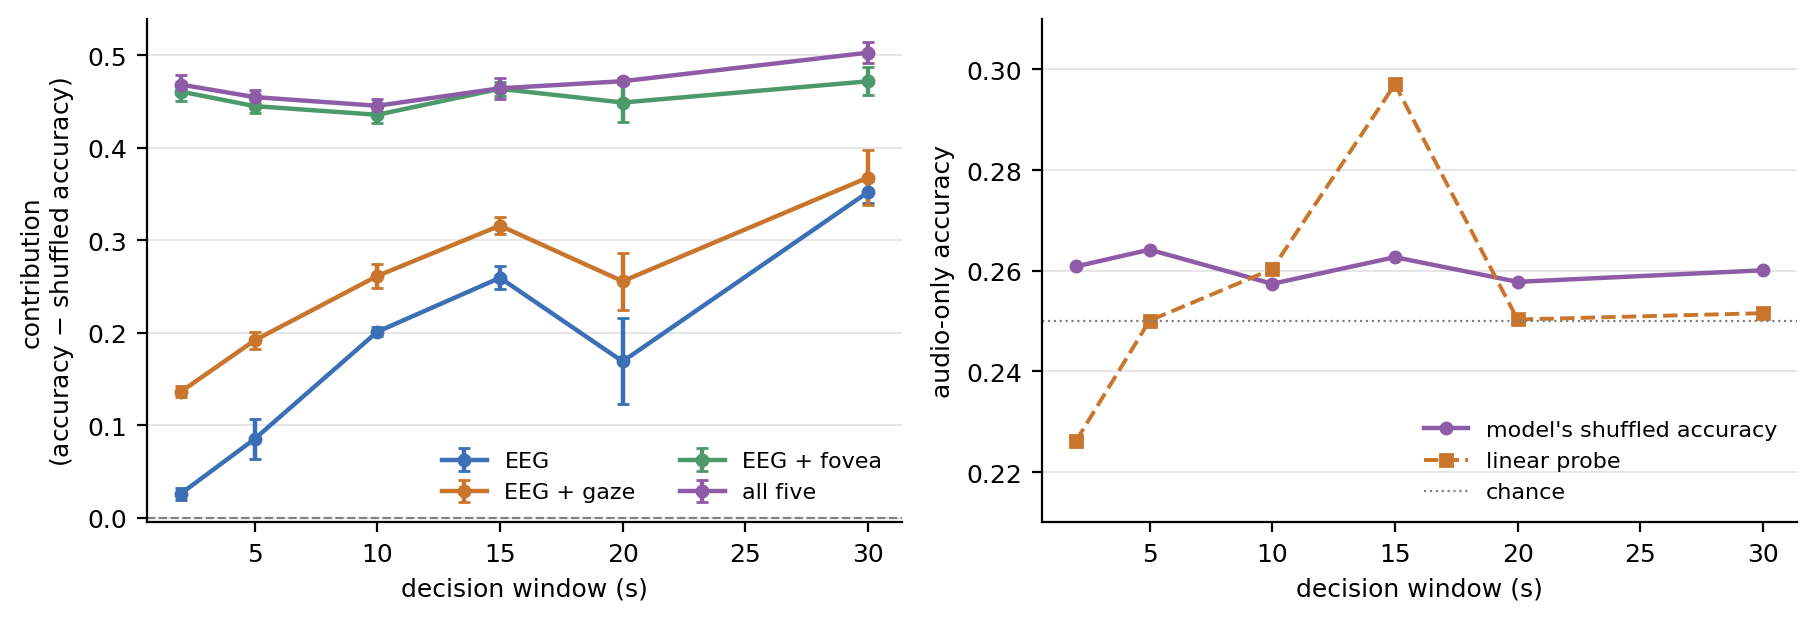

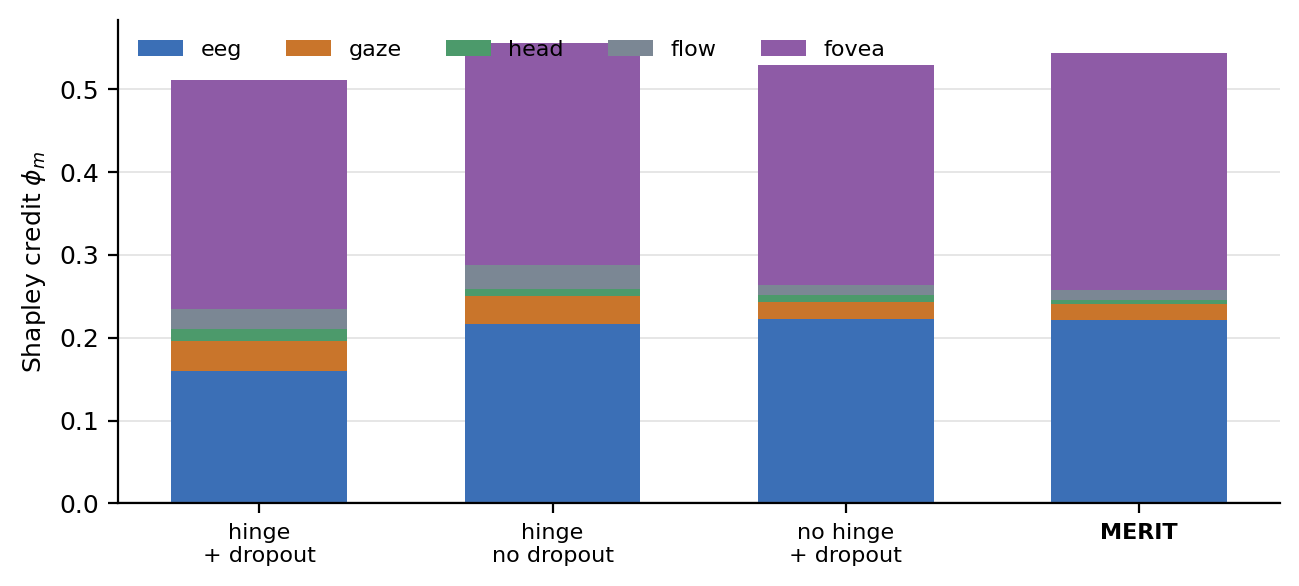

In [14]:
from IPython.display import Image, display
display(Image(filename=str(PAPER / "figs" / "window_sweep.png")))
display(Image(filename=str(PAPER / "figs" / "credit_bars.png")))

## 5 · The released checkpoints

`weights/merit/` holds one file per fold for the models the paper calls MERIT:

| folder | model | split | files |
|---|---|---|---|
| `fused_within/` | fused MERIT (EEG, gaze, head, flow, fovea; no hinge, no dropout) | 5 content-disjoint folds | 5 |
| `fused_loso/` | same model | leave-one-listener-out | 16 |
| `eeg_within/` | EEG-only MERIT (per-listener correction, onset channel) | 5 content-disjoint folds | 5 |

Each file carries `state_dict` + the full model `cfg`. They are **retrainings**
(the reported runs did not save weights — same code, data settings and folds;
GPU training is not bit-for-bit repeatable), so their accuracies sit within the
fold spread of the paper's numbers. The next cells load all 26 with
`strict=True` and put the released-run accuracies (tags `release*`, measured by
the very macros pipeline above) next to the paper's.

In [15]:
import torch
from omegaconf import OmegaConf
from src.models.merit.model import MeritModel

CKPTS = {fam: sorted((WEIGHTS / fam).glob("*.pt"))
         for fam in ("fused_within", "fused_loso", "eeg_within")}
rows, MODULES = [], {}
for fam, files in CKPTS.items():
    for f in files:
        ck = torch.load(f, map_location="cpu", weights_only=False)
        model = MeritModel(OmegaConf.create(ck["cfg"]), feature_dims={"n_candidates": 4})
        net = model.build_module()
        net.load_state_dict(ck["state_dict"], strict=True)   # raises on any mismatch
        MODULES[(fam, f.stem.split("__")[-1])] = (model, net)
        rows.append({"family": fam, "fold": f.stem.split("__")[-1],
                     "params": sum(p.numel() for p in net.parameters()),
                     "MB": round(f.stat().st_size / 1e6, 2)})
ck_df = pd.DataFrame(rows)
assert len(ck_df) == 26, "expected 26 checkpoints"
print(f"all {len(ck_df)} checkpoints load with strict=True")
ck_df.groupby("family").agg(files=("fold", "count"), params=("params", "first"),
                            MB=("MB", "sum"))

all 26 checkpoints load with strict=True


,files,params,MB
family,,,
eeg_within,5,12111,0.5
fused_loso,16,103399,8.0
fused_within,5,103399,2.5


In [16]:
REL = json.loads((WEIGHTS / "results.json").read_text())
comp = pd.DataFrame([
    {"family": fam,
     "released acc (mean)": np.mean([v["accuracy"] for v in REL[fam]["per_fold"].values()]),
     "released acc (macro)": float(R.get(mk, "nan")),
     "paper acc": float(R[pk]), "paper sd": float(R[pk.replace('/acc', '/accsd')])}
    for fam, mk, pk in [
        ("fused_within", "release/H4_nohinge_nodrop/within/acc",
         "v2hinge2/H4_nohinge_nodrop/within/acc"),
        ("fused_loso", "releaseloso/H4_nohinge_nodrop/loso/acc",
         "v2hinge2loso/H4_nohinge_nodrop/loso/acc"),
        ("eeg_within", "releaseeeg/V4_subjadapt/within/acc",
         "v2onset/V4_subjadapt/within/acc")]]).set_index("family")
comp["|release - paper|"] = (comp["released acc (mean)"] - comp["paper acc"]).abs()
assert (comp["|release - paper|"] < comp["paper sd"].clip(lower=0.02) + 0.02).all()
comp.round(4)

,released acc (mean),released acc (macro),paper acc,paper sd,|release - paper|
family,,,,,
fused_within,0.8204,0.8204,0.8173,0.0259,0.0031
fused_loso,0.7562,0.7563,0.7438,0.1931,0.0124
eeg_within,0.6732,0.6732,0.6915,0.0552,0.0183


## 6 · Re-score the released checkpoints on their exact test folds

The folds are fixed by seed 0, so `src/data/merit_data.py` rebuilds exactly the
test windows each checkpoint was scored on, and the shuffled-null / Shapley
battery uses common random numbers — re-scoring is **deterministic** and must
reproduce `weights/merit/results.json` to 4 decimals.

Data settings are those of `merit_release.sbatch`: 30 s trials, 10 s crops
(5 fixed eval crops), envelope + onset audio channel, per-listener EEG whitening
for the fused model. `RESCORE = "one"` scores one fold per family (~5 min CPU);
`"all"` re-scores all 26 (about an hour on CPU — use a GPU node for speed).

In [17]:
from src.data.merit_data import MeritDataModule
from src.models.merit.attribution import ContributionEvaluator

def release_dm(euclidean_align):
    return MeritDataModule(subjects="all", window_sec=30, hop_sec=15,
                           crop_len=640, n_train_crops=8, n_eval_crops=5,
                           euclidean_align=euclidean_align,
                           audio_feats="env_onset").prepare()

def rescore(model, net, test_view, device="cpu"):
    ev = ContributionEvaluator(net, test_view.as_torch_loader(model.batch_size),
                               device, strata=test_view.strata(),
                               trial_level=model.trial_level)
    return ev.battery(n_shuffle=model.test_shuffles, shapley=True)

FAMILIES = [("fused_within", "within", True), ("fused_loso", "loso", True),
            ("eeg_within", "within", False)]
rows = []
if RESCORE != "none":
    for align in (True, False):
        fams = [(f, p) for f, p, a in FAMILIES if a is align]
        if not fams:
            continue
        dm = release_dm(align)
        for fam, protocol in fams:
            views = {name: te for name, _, _, te in dm.splits(protocol)}
            folds = list(REL[fam]["per_fold"])
            for fold in (folds if RESCORE == "all" else folds[:1]):
                model, net = MODULES[(fam, fold)]
                t0 = time.time()
                b = rescore(model, net, views[fold])
                ref = REL[fam]["per_fold"][fold]
                rows.append({"family": fam, "fold": fold,
                             "acc": round(b["acc"], 4), "acc (released)": ref["accuracy"],
                             "null": round(b["null_mean"], 4),
                             "null (released)": ref["shuffled_accuracy"],
                             "contrib": round(b["contribution"], 4),
                             "contrib (released)": ref["contribution"],
                             "sec": round(time.time() - t0, 1)})
                print(rows[-1])
        del dm
res = pd.DataFrame(rows)
if len(res):
    dev = max((res["acc"] - res["acc (released)"]).abs().max(),
              (res["null"] - res["null (released)"]).abs().max(),
              (res["contrib"] - res["contrib (released)"]).abs().max())
    # CPU/GPU float order can flip a knife-edge window (1/1600 = 0.0006)
    assert dev < 0.002, f"re-score deviates from results.json by {dev}"
    print(f"\n{len(res)} fold(s) re-scored -- max deviation from results.json: {dev:.4f}")
res

{'family': 'fused_within', 'fold': 'within_f0', 'acc': 0.8031, 'acc (released)': 0.8031, 'null': 0.2784, 'null (released)': 0.2784, 'contrib': 0.5247, 'contrib (released)': 0.5247, 'sec': 196.8}


{'family': 'fused_loso', 'fold': 'loso_s1', 'acc': 0.55, 'acc (released)': 0.55, 'null': 0.2783, 'null (released)': 0.2783, 'contrib': 0.2718, 'contrib (released)': 0.2718, 'sec': 15.3}


{'family': 'eeg_within', 'fold': 'within_f0', 'acc': 0.675, 'acc (released)': 0.675, 'null': 0.3226, 'null (released)': 0.3225, 'contrib': 0.3524, 'contrib (released)': 0.3525, 'sec': 156.4}

3 fold(s) re-scored -- max deviation from results.json: 0.0001


,family,fold,acc,acc (released),null,null (released),contrib,contrib (released),sec
0,fused_within,within_f0,0.8031,0.8031,0.2784,0.2784,0.5247,0.5247,196.8
1,fused_loso,loso_s1,0.5500,0.5500,0.2783,0.2783,0.2718,0.2718,15.3
2,eeg_within,within_f0,0.6750,0.6750,0.3226,0.3225,0.3524,0.3525,156.4


## 7 · Build the PDF

`results_macros.tex` and `figs/` were just regenerated, so this compiles the
manuscript with the reproduced numbers in place. Any red `??` in the output
marks a claim whose measurement is missing.

In [18]:
if BUILD_PDF:
    subprocess.run(["latexmk", "-pdf", "-interaction=nonstopmode", "main.tex"],
                   cwd=PAPER, check=True)
    print("built", PAPER / "main.pdf")
else:
    print("skipped (set BUILD_PDF = True); last built PDF is docs/iclr2027/main.pdf")

skipped (set BUILD_PDF = True); last built PDF is docs/iclr2027/main.pdf


---
**Pointers.** Paper sources & build: `docs/iclr2027/README.md`. Checkpoint
format & loading: `weights/merit/README.md`. Results snapshot refresh:
`python -m src.tools.snapshot_results`. Console tables:
`python -m src.tools.report [--tag hinge] [--streams]`.